In [1]:
import sys
import maboss
import pandas as pd
import numpy as np
sys.path.append("/Users/emilieyu/endotehelial-masboss")
import matplotlib.pyplot as plt

from src.config import load_sim_config, load_sweep_config, load_spatial_config
from src.paths import *
from boolean_models.scripts import run_perturbations, run_sweeps

sim_cfg = load_sim_config()
sweep_cfg = load_sweep_config()
spatial_cfg = load_spatial_config()

from abm.flow_field import FlowField
from abm.endothelial_cell import EndothelialCell
from abm.membrane_node import MembraneNode
from abm.rho_lookup_table import RhoLookupTable

ipylab module is not installed, menus and toolbar are disabled.


## Full Pipeline Initial Runs

In [2]:
LUT = RhoLookupTable(cfg=spatial_cfg, recruitment_dir=BM_RESULTS_DIR)
cell = EndothelialCell(cell_id=0, centroid=np.array([0, 0]), lut=LUT, cfg=spatial_cfg)
flow_field = FlowField()
positions = cell.positions
centroid = cell.centroid


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Cleaned recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.463 RhoC=0.437
DEBUG: Initialised Cell 0: 
id=0 | n_nodes=12 | centroid=[-0.  0.] 
 target_area=300.000) | current_area=300.000


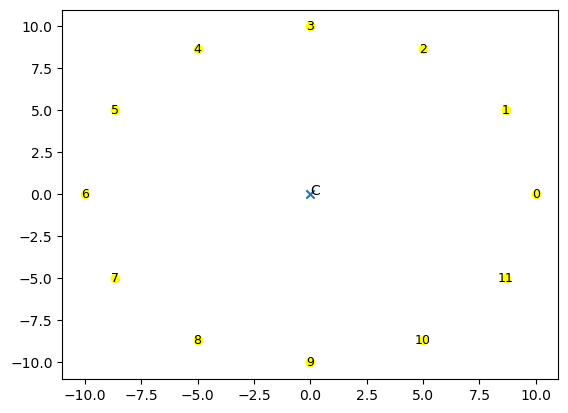

In [3]:
"""Node Overview"""

# Plot nodes
plt.scatter(positions[:,0], positions[:,1], color="yellow")

# Label nodes by ID
for node in cell.nodes:
    plt.text(node.pos[0], node.pos[1], str(node.id), fontsize=9,
             ha='center', va='center')

# Plot centroid
plt.scatter(centroid[0], centroid[1], marker="x")
plt.text(centroid[0], centroid[1], "C", fontsize=10, ha="left")
plt.show()
plt.close()

In [8]:
cell.step(flow_field, dt=0.1)
cell

>>> DEBUG: Calcualted Geometry for Spring 0
              diff: [-1.34  5.  ] | length: 5.18 | unit vect: [-0.26  0.97] | alignment: 0.26
>>> DEBUG: Calcualted Geometry for Spring 1
              diff: [-3.66  3.66] | length: 5.18 | unit vect: [-0.71  0.71] | alignment: 0.71
>>> DEBUG: Calcualted Geometry for Spring 2
              diff: [-5.    1.34] | length: 5.18 | unit vect: [-0.97  0.26] | alignment: 0.97
>>> DEBUG: Calcualted Geometry for Spring 3
              diff: [-5.   -1.34] | length: 5.18 | unit vect: [-0.97 -0.26] | alignment: 0.97
>>> DEBUG: Calcualted Geometry for Spring 4
              diff: [-3.66 -3.66] | length: 5.18 | unit vect: [-0.71 -0.71] | alignment: 0.71
>>> DEBUG: Calcualted Geometry for Spring 5
              diff: [-1.34 -5.  ] | length: 5.18 | unit vect: [-0.26 -0.97] | alignment: 0.26
>>> DEBUG: Calcualted Geometry for Spring 6
              diff: [ 1.34 -5.  ] | length: 5.18 | unit vect: [ 0.26 -0.97] | alignment: 0.26
>>> DEBUG: Calcualted Geometry for

id=0 | n_nodes=12 | centroid=[0.3 0. ] 
 target_area=300.000) | current_area=300.000

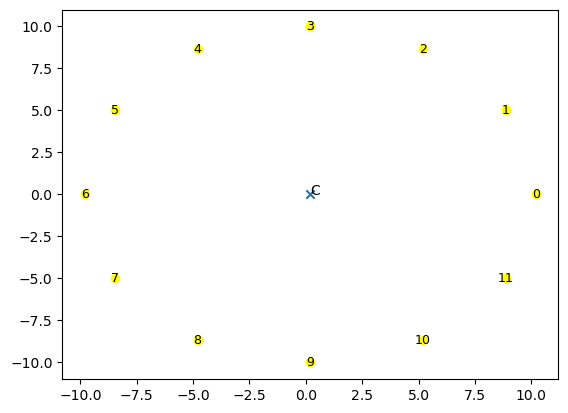

In [7]:
plt.scatter(cell.positions[:,0], cell.positions[:,1], color="yellow")

# Label nodes by ID
for node in cell.nodes:
    plt.text(node.pos[0], node.pos[1], str(node.id), fontsize=9,
             ha='center', va='center')

# Plot centroid
plt.scatter(cell.centroid[0], cell.centroid[1], marker="x")
plt.text(cell.centroid[0], cell.centroid[1], "C", fontsize=10, ha="left")
plt.show()
plt.close()

## Test ABM Classes

### Initiate Cell and Flow

In [11]:
# Initiate cell and flow field
cell = EndothelialCell(0, np.array([0.0, 0.0]))
field = FlowField()

# Initae cell propetues
positions = cell.positions
centroid = cell.centroid
nodes = cell.nodes
springs = cell.springs

node0 = nodes[0]
node3 = nodes[3]
node6 = nodes[6]
node9 = nodes[9]

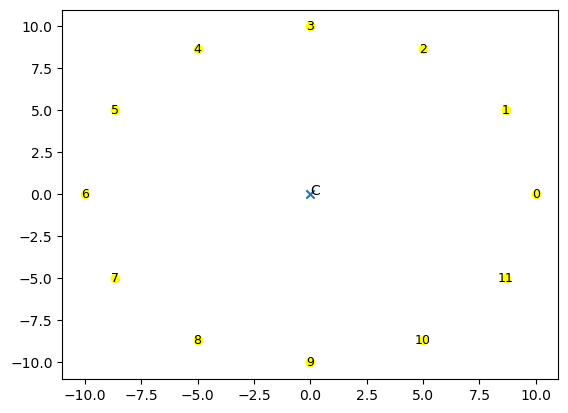

Initial Node State: 
MembraneNode(id=0 | pos=[10.  0.] | force=[0. 0.]
MembraneNode(id=1 | pos=[8.66 5.  ] | force=[0. 0.]
MembraneNode(id=2 | pos=[5.   8.66] | force=[0. 0.]
MembraneNode(id=3 | pos=[ 0. 10.] | force=[0. 0.]
MembraneNode(id=4 | pos=[-5.    8.66] | force=[0. 0.]
MembraneNode(id=5 | pos=[-8.66  5.  ] | force=[0. 0.]
MembraneNode(id=6 | pos=[-10.   0.] | force=[0. 0.]
MembraneNode(id=7 | pos=[-8.66 -5.  ] | force=[0. 0.]
MembraneNode(id=8 | pos=[-5.   -8.66] | force=[0. 0.]
MembraneNode(id=9 | pos=[ -0. -10.] | force=[0. 0.]
MembraneNode(id=10 | pos=[ 5.   -8.66] | force=[0. 0.]
MembraneNode(id=11 | pos=[ 8.66 -5.  ] | force=[0. 0.]
Initial Sping State: 
[Spring(0→1 | L=5.176 L0=5.176 | T=0.000 align=0.000 | DSP=0 TJP1=0 JCAD=0 | RhoA=0.000 RhoC=0.000), Spring(1→2 | L=5.176 L0=5.176 | T=0.000 align=0.000 | DSP=0 TJP1=0 JCAD=0 | RhoA=0.000 RhoC=0.000), Spring(2→3 | L=5.176 L0=5.176 | T=0.000 align=0.000 | DSP=0 TJP1=0 JCAD=0 | RhoA=0.000 RhoC=0.000), Spring(3→4 | L=5.176 L

In [ ]:
"""Node Overview"""

# Plot nodes
plt.scatter(positions[:,0], positions[:,1], color="yellow")

# Label nodes by ID
for node in cell.nodes:
    plt.text(node.pos[0], node.pos[1], str(node.id), fontsize=9,
             ha='center', va='center')

# Plot centroid
plt.scatter(centroid[0], centroid[1], marker="x")
plt.text(centroid[0], centroid[1], "C", fontsize=10, ha="left")
plt.show()
plt.close()

print("Initial Node State: ")
for node in cell.nodes: 
    print(node)


print("Initial Sping State: ")
for spring in cell.springs: 
    print(spring)

### Cell and Nodes after applying flow

In [13]:
flow_force = field.get_force_on_node()
flow_force

print("Nodes after applying force from flow")
for node in cell.nodes: 
    node.apply_force(flow_force)
    print(node)

print("Spring after updating geometry")
for spring in springs: 
    spring.update_geometry(field.direction)
    print(spring)

Nodes after applying force from flow
MembraneNode(id=0 | pos=[10.  0.] | force=[1. 0.]
MembraneNode(id=1 | pos=[8.66 5.  ] | force=[1. 0.]
MembraneNode(id=2 | pos=[5.   8.66] | force=[1. 0.]
MembraneNode(id=3 | pos=[ 0. 10.] | force=[1. 0.]
MembraneNode(id=4 | pos=[-5.    8.66] | force=[1. 0.]
MembraneNode(id=5 | pos=[-8.66  5.  ] | force=[1. 0.]
MembraneNode(id=6 | pos=[-10.   0.] | force=[1. 0.]
MembraneNode(id=7 | pos=[-8.66 -5.  ] | force=[1. 0.]
MembraneNode(id=8 | pos=[-5.   -8.66] | force=[1. 0.]
MembraneNode(id=9 | pos=[ -0. -10.] | force=[1. 0.]
MembraneNode(id=10 | pos=[ 5.   -8.66] | force=[1. 0.]
MembraneNode(id=11 | pos=[ 8.66 -5.  ] | force=[1. 0.]
Spring after updating geometry
Spring(0→1 | L=5.176 L0=5.176 | T=-0.000 align=0.259 | DSP=0 TJP1=0 JCAD=0 | RhoA=0.000 RhoC=0.000)
Spring(1→2 | L=5.176 L0=5.176 | T=0.000 align=0.707 | DSP=0 TJP1=0 JCAD=0 | RhoA=0.000 RhoC=0.000)
Spring(2→3 | L=5.176 L0=5.176 | T=0.000 align=0.966 | DSP=0 TJP1=0 JCAD=0 | RhoA=0.000 RhoC=0.000)


In [16]:
for spring in springs:
    spring.get_spring_mechanical_inputs()

>>> DEBUG: Computed mechnical input tau_dsp: 0.0, tau_tjp1: 0.0, tau_jcad: 0
>>> DEBUG: Computed mechnical input tau_dsp: 0.0, tau_tjp1: 0.0, tau_jcad: 0.0
>>> DEBUG: Computed mechnical input tau_dsp: 8.579144739409623e-16, tau_tjp1: 3.0263945759162957e-17, tau_jcad: 8.881784197001252e-16
>>> DEBUG: Computed mechnical input tau_dsp: 0.0, tau_tjp1: 0.0, tau_jcad: 0
>>> DEBUG: Computed mechnical input tau_dsp: 0.0, tau_tjp1: 0.0, tau_jcad: 0
>>> DEBUG: Computed mechnical input tau_dsp: 9.195099618698094e-16, tau_tjp1: 2.6332037169306917e-15, tau_jcad: 3.552713678800501e-15
>>> DEBUG: Computed mechnical input tau_dsp: 0.0, tau_tjp1: 0.0, tau_jcad: 0
>>> DEBUG: Computed mechnical input tau_dsp: 0.0, tau_tjp1: 0.0, tau_jcad: 0
>>> DEBUG: Computed mechnical input tau_dsp: 4.289572369704811e-15, tau_tjp1: 1.5131972879581528e-16, tau_jcad: 4.440892098500626e-15
>>> DEBUG: Computed mechnical input tau_dsp: 0.0, tau_tjp1: 0.0, tau_jcad: 0
>>> DEBUG: Computed mechnical input tau_dsp: 2.5121479338

### Mathematical Properties Testing

In [36]:
""" All outward normals should have magnitude 1 – they are unit vectors"""
centre = cell.centroid
normals = flow.compute_normals(cell.positions, centre)
magnitudes = np.linalg.norm(normals, axis=1)
print(f"normals: {normals}\nmagnitudes: {magnitudes}")

normals: [[ 1.00000000e+00 -7.40148683e-18]
 [ 8.66025404e-01  5.00000000e-01]
 [ 5.00000000e-01  8.66025404e-01]
 [ 1.79656129e-16  1.00000000e+00]
 [-5.00000000e-01  8.66025404e-01]
 [-8.66025404e-01  5.00000000e-01]
 [-1.00000000e+00  1.15063193e-16]
 [-8.66025404e-01 -5.00000000e-01]
 [-5.00000000e-01 -8.66025404e-01]
 [-6.52732306e-17 -1.00000000e+00]
 [ 5.00000000e-01 -8.66025404e-01]
 [ 8.66025404e-01 -5.00000000e-01]]
magnitudes: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [37]:
""" Check faces are correctly classified"""
faces = flow.classify_faces(normals)
for i, (f, n) in enumerate(zip(faces, normals)):
    print(f"  Node {i:2d}: normal={n.round(3)} → {f}")

  Node  0: normal=[ 1. -0.] → upstream
  Node  1: normal=[0.866 0.5  ] → upstream
  Node  2: normal=[0.5   0.866] → lateral
  Node  3: normal=[0. 1.] → lateral
  Node  4: normal=[-0.5    0.866] → lateral
  Node  5: normal=[-0.866  0.5  ] → downstream
  Node  6: normal=[-1.  0.] → downstream
  Node  7: normal=[-0.866 -0.5  ] → downstream
  Node  8: normal=[-0.5   -0.866] → lateral
  Node  9: normal=[-0. -1.] → lateral
  Node 10: normal=[ 0.5   -0.866] → lateral
  Node 11: normal=[ 0.866 -0.5  ] → upstream
